<h1 style="color: darkblue; text-align: center;">
    FASHION SALES DATA
</h1>

<h2 style="color: royalblue; text-align: center;">
    Project Overview
</h2>

<p style="text-align: left;">
This project analyzes dress attributes and predicts whether a dress will be recommended based on sales data.
This dataset contain attributes of dresses and their recommendations according to their sales. Sales are monitored on the basis of alternate days.

This project focuses on cleaning and exploring a fashion dress e-commerce dataset. The dataset contains dress attributes such as style, price, rating, season, material, and fabric type, along with customer recommendation data.
   
The raw data contained several quality issues including missing values represented as ?, zeros in the Rating column, and incomplete value mappings. These were systematically handled by replacing ? with NaN, filling text columns with mode, and filling numeric columns with median.

New derived columns were engineered including RatingCategory, PriceLevel, and IsRecommended to enhance analysis. The dataset was then explored through Exploratory Data Analysis (EDA) to uncover patterns in customer preferences, pricing trends, and product recommendations.
</p>



## TOOLS

##### Jupyter Notebook    -- Writing and executing the project code interactively
##### CSV Export (pandas) -- Saving the cleaned dataset for future use
##### ARFF Format (Weka)  -- Original data source format used in ML tools

## LIBRARIES

##### scipy.io (arff)     -- Load the raw ARFF dataset
##### NumPy               -- Numerical operations, handling NaN
##### Pandas              -- Data manipulation & analysis
##### Matplotlib          -- Static data visualization
##### Seaborn             -- Statistical visualization
##### Plotly              -- Interactive visualizations

## 1. Data Loading

The dataset was originally in **ARFF (Attribute-Relation File Format)**, 
which is commonly used in machine learning tools like Weka.

The data was loaded using `scipy.io.arff` and converted into a 
**Pandas DataFrame** for easy analysis. A copy was saved as CSV 
for future reference.

In [1]:
from scipy.io import arff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1 : Load ARFF

data, meta = arff.loadarff(r"C:\Users\Rosem\OneDrive\Desktop\DATA ANAYLTICS ASSIGNMENT\Phython Programs assignment\phpcFPMhq.arff")

# Step 2 : Converting to Dataframe
df = pd.DataFrame(data)

df.to_csv(r"C:\Users\Rosem\OneDrive\Desktop\DATA ANAYLTICS ASSIGNMENT\Phython Programs assignment\fashions sales.csv",index=False)

print("✅ Done! CSV saved successfully!")
print(df.head())


✅ Done! CSV saved successfully!
           V2          V3   V4    V5         V6         V7            V8  \
0     b'Sexy'      b'Low'  4.6  b'M'  b'Summer'  b'o-neck'  b'sleevless'   
1   b'Casual'      b'Low'  0.0  b'L'  b'Summer'  b'o-neck'      b'Petal'   
2  b'vintage'     b'High'  0.0  b'L'  b'Automn'  b'o-neck'       b'full'   
3    b'Brief'  b'Average'  4.6  b'L'  b'Spring'  b'o-neck'       b'full'   
4     b'cute'      b'Low'  4.5  b'M'  b'Summer'  b'o-neck'  b'butterfly'   

           V9               V10         V11            V12        V13 Class  
0   b'empire'              b'?'  b'chiffon'     b'ruffles'  b'animal'  b'2'  
1  b'natural'     b'microfiber'        b'?'     b'ruffles'  b'animal'  b'1'  
2  b'natural'       b'polyster'        b'?'           b'?'   b'print'  b'1'  
3  b'natural'           b'silk'  b'chiffon'  b'embroidary'   b'print'  b'2'  
4  b'natural'  b'chiffonfabric'  b'chiffon'         b'bow'     b'dot'  b'1'  


## Step 2: Decoding Data

After loading from ARFF format, all text columns are stored 
as **bytes** (b'value') instead of normal strings.
This step converts them to readable **UTF-8 text format**.

In [2]:
# Decode

df = df.apply(lambda col: col.str.decode('utf-8') if col.dtype == object else col)

print(df.head())

        V2       V3   V4 V5      V6      V7         V8       V9  \
0     Sexy      Low  4.6  M  Summer  o-neck  sleevless   empire   
1   Casual      Low  0.0  L  Summer  o-neck      Petal  natural   
2  vintage     High  0.0  L  Automn  o-neck       full  natural   
3    Brief  Average  4.6  L  Spring  o-neck       full  natural   
4     cute      Low  4.5  M  Summer  o-neck  butterfly  natural   

             V10      V11         V12     V13 Class  
0              ?  chiffon     ruffles  animal     2  
1     microfiber        ?     ruffles  animal     1  
2       polyster        ?           ?   print     1  
3           silk  chiffon  embroidary   print     2  
4  chiffonfabric  chiffon         bow     dot     1  


## Step 3: Renaming Columns

The original ARFF file contained unclear or 
inconsistent column names. This step renames all 
columns to **meaningful and readable names** 
for better understanding during analysis.

In [3]:
# Step 3 : RENAME COLUMNS

df.columns = ['Style', 'Price', 'Rating', 'Size', 'Season',
              'NeckLine', 'SleeveLength', 'Waistline',
              'Material', 'FabricType', 'Decoration',
              'PatternType', 'Recommendation']

print(df.head())

     Style    Price  Rating Size  Season NeckLine SleeveLength Waistline  \
0     Sexy      Low     4.6    M  Summer   o-neck    sleevless    empire   
1   Casual      Low     0.0    L  Summer   o-neck        Petal   natural   
2  vintage     High     0.0    L  Automn   o-neck         full   natural   
3    Brief  Average     4.6    L  Spring   o-neck         full   natural   
4     cute      Low     4.5    M  Summer   o-neck    butterfly   natural   

        Material FabricType  Decoration PatternType Recommendation  
0              ?    chiffon     ruffles      animal              2  
1     microfiber          ?     ruffles      animal              1  
2       polyster          ?           ?       print              1  
3           silk    chiffon  embroidary       print              2  
4  chiffonfabric    chiffon         bow         dot              1  


## Step 4: Handling Missing Values — Replacing ? with NaN

The dataset used **'?'** as a placeholder for missing values
instead of standard null values. This step identifies and 
converts all **'?'** to proper **NaN (Not a Number)** format
so that pandas can detect and handle them correctly.

In [4]:
# Missing Values ( In data missing values is mentioned as ?)

# 1. REPLACE ? WITH NaN

print("=" * 55)
print("STEP 1: REPLACE ? WITH NaN")
print("=" * 55)
print("BEFORE:")
print(df.isnull().sum())

df.replace('?', np.nan, inplace=True)

print("\nAFTER:")
print(df.isnull().sum())


STEP 1: REPLACE ? WITH NaN
BEFORE:
Style             0
Price             0
Rating            0
Size              0
Season            0
NeckLine          0
SleeveLength      0
Waistline         0
Material          0
FabricType        0
Decoration        0
PatternType       0
Recommendation    0
dtype: int64

AFTER:
Style               0
Price               2
Rating              0
Size                0
Season              2
NeckLine            3
SleeveLength        2
Waistline          87
Material          128
FabricType        266
Decoration        236
PatternType       109
Recommendation      0
dtype: int64


## Step 5: Filling Missing Values in Text Columns — Mode Imputation

After replacing '?' with NaN, all text columns with 
missing values are filled with the **MODE** (most frequently 
occurring value) of that column. This ensures no missing 
values remain in categorical columns while preserving 
the most common pattern in the data.

In [5]:
# Replaced ? with NaN first, then filled with mode:

text_cols = ['Style', 'Price', 'Size', 'Season', 'NeckLine',
             'SleeveLength', 'Waistline', 'Material',
             'FabricType', 'Decoration', 'PatternType']

for col in text_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(df[text_cols].isnull().sum())

Style           0
Price           0
Size            0
Season          0
NeckLine        0
SleeveLength    0
Waistline       0
Material        0
FabricType      0
Decoration      0
PatternType     0
dtype: int64


## Step 6: Fixing Rating Column — Replacing Zeros with Median

The **Rating column** contained **120 zeros** which are 
invalid ratings. A rating of 0 is not meaningful in a 
1-5 scale, so they are treated as missing values.

The zeros are first converted to **NaN** and then filled 
with the **MEDIAN** rating to preserve the true average 
without being affected by extreme values.

In [6]:
# Checking if the rating has 0 (Numeric data)

print((df['Rating'] == 0).sum())

120


In [7]:
# Filled rating with Mean

# Step 1: Replace 0 with NaN

df['Rating'] = df['Rating'].replace(0, np.nan)

In [8]:
# Step 2: Fill with median
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

# Step 3: Verify
print(f"Zeros remaining: {(df['Rating'] == 0).sum()}")
print(f"NaN remaining: {df['Rating'].isnull().sum()}")
print(f"Median Rating: {df['Rating'].median()}")

Zeros remaining: 0
NaN remaining: 0
Median Rating: 4.7


## Step 7: Dataset Overview — Rows and Columns

This step provides a quick overview of the **size and 
structure** of the dataset by checking the total number 
of rows, columns, and cells. This helps understand the 
scale of data we are working with before deeper analysis.

In [9]:
# Data Loading and Initial Overview

# 2. NUMBER OF ROWS AND COLUMNS

print("=" * 55)
print("2. NUMBER OF ROWS AND COLUMNS")
print("=" * 55)
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")
print(f"Total Cells       : {df.shape[0] * df.shape[1]}")

2. NUMBER OF ROWS AND COLUMNS
Number of Rows    : 500
Number of Columns : 13
Total Cells       : 6500


## Step 8: Data Types of Each Column

Understanding the **data type** of each column is essential 
before analysis. This step checks whether each column is 
stored as text, number, or category — ensuring the right 
operations are applied to the right columns.

In [10]:
# 3. DATA TYPES OF EACH COLUMN

print("\n" + "=" * 55)
print("3. DATA TYPES OF EACH COLUMN")
print("=" * 55)
print(df.dtypes)


3. DATA TYPES OF EACH COLUMN
Style              object
Price              object
Rating            float64
Size               object
Season             object
NeckLine           object
SleeveLength       object
Waistline          object
Material           object
FabricType         object
Decoration         object
PatternType        object
Recommendation     object
dtype: object


## Step 9: Dataset Information — info()

The **info()** function provides a complete summary of the 
dataset in one shot. It shows column names, data types, 
non-null counts and memory usage — giving a full health 
check of the dataset at a glance.

In [11]:
# 4. DATASET INFO - info()

print("\n" + "=" * 55)
print("4. DATASET INFO - info()")
print("=" * 55)
df.info()


4. DATASET INFO - info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Style           500 non-null    object 
 1   Price           500 non-null    object 
 2   Rating          500 non-null    float64
 3   Size            500 non-null    object 
 4   Season          500 non-null    object 
 5   NeckLine        500 non-null    object 
 6   SleeveLength    500 non-null    object 
 7   Waistline       500 non-null    object 
 8   Material        500 non-null    object 
 9   FabricType      500 non-null    object 
 10  Decoration      500 non-null    object 
 11  PatternType     500 non-null    object 
 12  Recommendation  500 non-null    object 
dtypes: float64(1), object(12)
memory usage: 50.9+ KB


## Step 10: Statistical Summary — describe()

The **describe()** function generates a complete statistical 
summary of the dataset. It is applied separately to 
**numeric columns** and **categorical columns** to get 
meaningful statistics for each type.

In [12]:
# 5. STATISTICAL SUMMARY - describe()

print("\n" + "=" * 55)
print("5. STATISTICAL SUMMARY - describe()")
print("=" * 55)
print("\n-- Numeric Columns --")
print(df.describe())

print("\n-- Categorical Columns --")
print(df.describe(include='object'))


5. STATISTICAL SUMMARY - describe()

-- Numeric Columns --
           Rating
count  500.000000
mean     4.656600
std      0.286882
min      1.000000
25%      4.600000
50%      4.700000
75%      4.800000
max      5.000000

-- Categorical Columns --
         Style    Price Size  Season NeckLine SleeveLength Waistline Material  \
count      500      500  500     500      500          500       500      500   
unique      13        7    7       8       16           17         4       23   
top     Casual  Average    M  Summer   o-neck    sleevless   natural   cotton   
freq       232      254  177     161      274          225       391      280   

       FabricType Decoration PatternType Recommendation  
count         500        500         500            500  
unique         22         24          14              2  
top       chiffon       lace       solid              1  
freq          401        306         312            290  


## Step 11: Fixing Text Casing and Whitespace

Text columns often contain **inconsistent casing** and 
**extra spaces** which cause duplicates during analysis.
For example 'Summer', 'summer', and 'SUMMER ' are treated 
as 3 different values even though they mean the same thing.
This step standardizes all text to **lowercase** and 
removes **leading/trailing spaces**.

In [13]:
# 7. Fix casing

text_cols = ['Style', 'Price', 'Size', 'Season', 'NeckLine',
             'SleeveLength', 'Waistline', 'Material',
             'FabricType', 'Decoration', 'PatternType']
for col in text_cols:
    df[col] = df[col].str.lower().str.strip()

print("=" * 55)
print("AFTER CASING FIX - unique values per column")
print("=" * 55)

for col in text_cols:
    print(f"\n{col}:")
    print(df[col].unique())

AFTER CASING FIX - unique values per column

Style:
['sexy' 'casual' 'vintage' 'brief' 'cute' 'bohemian' 'novelty' 'flare'
 'party' 'work' 'ol' 'fashion']

Price:
['low' 'high' 'average' 'medium' 'very-high']

Size:
['m' 'l' 'xl' 'free' 's' 'small']

Season:
['summer' 'automn' 'spring' 'winter' 'autumn']

NeckLine:
['o-neck' 'v-neck' 'boat-neck' 'peterpan-collor' 'ruffled'
 'turndowncollor' 'slash-neck' 'mandarin-collor' 'open' 'sqare-collor'
 'sweetheart' 'scoop' 'halter' 'backless' 'bowneck']

SleeveLength:
['sleevless' 'petal' 'full' 'butterfly' 'short' 'threequarter'
 'halfsleeve' 'cap-sleeves' 'turndowncollor' 'threequater' 'capsleeves'
 'sleeveless' 'sleeevless' 'half' 'urndowncollor' 'thressqatar'
 'sleveless']

Waistline:
['empire' 'natural' 'princess' 'dropped']

Material:
['cotton' 'microfiber' 'polyster' 'silk' 'chiffonfabric' 'nylon' 'other'
 'milksilk' 'linen' 'rayon' 'lycra' 'mix' 'acrylic' 'spandex' 'lace'
 'modal' 'cashmere' 'viscos' 'knitting' 'sill' 'wool' 'model' 'sh

## Step 12: Fixing Spelling Errors

The dataset contained several **spelling mistakes** across 
multiple columns. These errors cause the same category to 
be treated as different values during analysis.
This step corrects all spelling mistakes using a 
**replacement dictionary** and verifies the fixes.

In [14]:
# 8. Fix Spelling

df['Season'] = df['Season'].replace({'automn': 'autumn'})
df['SleeveLength'] = df['SleeveLength'].replace({
                        'sleevless'  : 'sleeveless',
                        'sleeevless' : 'sleeveless',
                        'sleveless'  : 'sleeveless',
                        'threequater': 'threequarter',
                        'thressqatar': 'threequarter',
                        'cap-sleeves': 'capsleeves',
                        'halfsleeve' : 'halfsleeves'})
df['Material'] = df['Material'].replace({
                        'polyster'     : 'polyester',
                        'chiffonfabric': 'chiffon',
                        'shiffon'      : 'chiffon',
                        'sill'         : 'silk',
                        'model'        : 'modal'})
df['FabricType'] = df['FabricType'].replace({
                        'shiffon' : 'chiffon',
                        'flannael': 'flannel',
                        'sattin'  : 'satin',
                        'wollen'  : 'woolen'})

print("\n" + "=" * 55)
print("VERIFICATION - RANDOM CHECK")
print("=" * 55)
print("'automn' gone?      :", 'automn'      not in df['Season'].values)
print("'sleevless' gone?   :", 'sleevless'   not in df['SleeveLength'].values)
print("'threequater' gone? :", 'threequater' not in df['SleeveLength'].values)
print("'polyster' gone?    :", 'polyster'    not in df['Material'].values)
print("'shiffon' gone?     :", 'shiffon'     not in df['FabricType'].values)
print("'flannael' gone?    :", 'flannael'    not in df['FabricType'].values)


VERIFICATION - RANDOM CHECK
'automn' gone?      : True
'sleevless' gone?   : True
'threequater' gone? : True
'polyster' gone?    : True
'shiffon' gone?     : True
'flannael' gone?    : True


## Step 13: Identifying Duplicate Rows

Before removing duplicates, this step **identifies and counts** 
how many duplicate rows exist in the dataset. 
Duplicate rows are identical records that appear more than 
once and can **skew analysis results** if not removed.

In [15]:
# Removing Duplicates

print("\n" + "=" * 55)
print("2. REMOVING DUPLICATES")
print("=" * 55)
print(f"BEFORE: {df.shape[0]} rows")
print(f"Duplicate rows found: {df.duplicated().sum()}")



2. REMOVING DUPLICATES
BEFORE: 500 rows
Duplicate rows found: 1


In [16]:
df = df.drop_duplicates()

print(f"AFTER : {df.shape[0]} rows")
print(f"Duplicates removed  : {df.duplicated().sum()}")

AFTER : 499 rows
Duplicates removed  : 0


## Step 14: Correcting Data Types

After cleaning, each column must be stored in the 
**correct data type** for accurate analysis. 
This step checks the current datatypes before making 
corrections — ensuring numeric columns can perform 
calculations and text columns are stored efficiently 
as categories.

In [17]:
# Correcting Datatypes

print("\n" + "=" * 55)
print("3. CORRECTING DATA TYPES")
print("=" * 55)
print("BEFORE:")
print(df.dtypes)



3. CORRECTING DATA TYPES
BEFORE:
Style              object
Price              object
Rating            float64
Size               object
Season             object
NeckLine           object
SleeveLength       object
Waistline          object
Material           object
FabricType         object
Decoration         object
PatternType        object
Recommendation     object
dtype: object


In [18]:
df['Recommendation'] = df['Recommendation'].astype(int)

In [19]:
df['Rating'] = df['Rating'].astype(float)

In [20]:
for col in text_cols:
    df[col] = df[col].astype('category')

print("\nAFTER:")
print(df.dtypes)


AFTER:
Style             category
Price             category
Rating             float64
Size              category
Season            category
NeckLine          category
SleeveLength      category
Waistline         category
Material          category
FabricType        category
Decoration        category
PatternType       category
Recommendation       int64
dtype: object


## Step 15: Creating Derived Columns

Derived columns are **new columns created from existing ones** 
to enhance analysis. 

1. This step creates a **RatingCategory** 
column by converting the numeric Rating into meaningful 
text labels using defined ranges (bins).


2. This step creates a **PriceLevel** column by converting 
the text-based Price column into **ordered numeric values**.

3. This step creates an **IsRecommended** column by converting 
the numeric Recommendation column (1 and 2) into meaningful 
**text labels**.


In [21]:
# 1.Creating Derived columns

print("\n" + "=" * 55)
print("4. CREATING DERIVED COLUMNS")
print("=" * 55)

# Derived column 1: Rating Category
df['RatingCategory'] = pd.cut(
    df['Rating'],
    bins    = [0, 3, 4, 4.5, 5],
    labels  = ['Poor', 'Good', 'Very Good', 'Excellent']
)
print("RatingCategory created:")
print(df['RatingCategory'].value_counts())



4. CREATING DERIVED COLUMNS
RatingCategory created:
RatingCategory
Excellent    394
Very Good     92
Good          11
Poor           2
Name: count, dtype: int64


In [22]:
# Derived column 2: PriceLevel (numeric mapping)
price_map = {
    'low'      : 1,
    'average'  : 2,
    'medium'   : 3,
    'high'     : 4,
    'very-high': 5
}
df['PriceLevel'] = df['Price'].map(price_map)
print("\nPriceLevel created:")
print(df['PriceLevel'].value_counts())



PriceLevel created:
PriceLevel
2    254
1    173
3     30
4     21
5     21
Name: count, dtype: int64


In [23]:
# Derived column 3: IsRecommended label
df['IsRecommended'] = df['Recommendation'].map({
    0: 'Not Recommended',
    1: 'Recommended',
    2: 'Not Recommended'
})
print("\nIsRecommended created:")
print(df['IsRecommended'].value_counts())

print("\nNew columns added:")
print(df[['Rating', 'RatingCategory', 'Price',
          'PriceLevel', 'Recommendation',
          'IsRecommended']].head(10))


IsRecommended created:
IsRecommended
Recommended        289
Not Recommended    210
Name: count, dtype: int64

New columns added:
   Rating RatingCategory    Price PriceLevel  Recommendation    IsRecommended
0     4.6      Excellent      low          1               2  Not Recommended
1     4.7      Excellent      low          1               1      Recommended
2     4.7      Excellent     high          4               1      Recommended
3     4.6      Excellent  average          2               2  Not Recommended
4     4.5      Very Good      low          1               1      Recommended
5     4.7      Excellent      low          1               1      Recommended
6     4.7      Excellent  average          2               1      Recommended
7     4.7      Excellent  average          2               1      Recommended
8     4.7      Excellent  average          2               2  Not Recommended
9     4.7      Excellent      low          1               2  Not Recommended


## FILTERING DATA

In this section, we perform data filtering to extract specific subsets of the dataset based on different conditions. This helps in understanding patterns such as customer preferences, product ratings, and seasonal trends.

In [24]:
# Filtering Data

print("\n" + "=" * 55)
print("5. FILTERING DATA")
print("=" * 55)

# Filter 1: Only recommended dresses
recommended = df[df['Recommendation'] == 1]
print(f"Total Recommended dresses     : {len(recommended)}")


5. FILTERING DATA
Total Recommended dresses     : 289


In [25]:
# Filter 2: Only not recommended dresses

not_recommended = df[df['Recommendation'] == 2]
print(f"Total Not Recommended dresses : {len(not_recommended)}")

Total Not Recommended dresses : 210


In [26]:
# Filter 3: High rated dresses (rating >= 4.5)

high_rated = df[df['Rating'] >= 4.5]
print(f"High Rated dresses (>=4.5)    : {len(high_rated)}")

High Rated dresses (>=4.5)    : 428


In [27]:
# Filter 4: Casual style dresses
casual = df[df['Style'] == 'casual']
print(f"Casual style dresses          : {len(casual)}")

Casual style dresses          : 231


In [28]:
# Filter 5: Summer dresses
summer = df[df['Season'] == 'summer']
print(f"Summer dresses                : {len(summer)}")

Summer dresses                : 161


## AGGREGATING 

In this section, we perform data aggregation using the groupby() function to summarize the dataset. 

Aggregation helps in identifying trends and patterns by grouping data based on categories such as style and season.

In [29]:
print("\n" + "=" * 55)
print("6. AGGREGATING DATA")
print("=" * 55)

# Aggregation 1: Average rating per Style
print("Average Rating per Style:")
print(df.groupby('Style')['Rating'].mean().round(2))


6. AGGREGATING DATA
Average Rating per Style:
Style
bohemian    4.70
brief       4.63
casual      4.63
cute        4.66
fashion     4.00
flare       4.70
novelty     4.73
ol          4.70
party       4.73
sexy        4.66
vintage     4.67
work        4.74
Name: Rating, dtype: float64


C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\3272588407.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Style')['Rating'].mean().round(2))


In [30]:
# Aggregation 2: Average rating per Season
print("\nAverage Rating per Season:")
print(df.groupby('Season')['Rating'].mean().round(2))


Average Rating per Season:
Season
autumn    4.63
spring    4.68
summer    4.65
winter    4.65
Name: Rating, dtype: float64


C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\1062038497.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Season')['Rating'].mean().round(2))


In [31]:
# Aggregation 3: Count of dresses per Style
print("\nCount of dresses per Style:")
print(df.groupby('Style')['Style'].count())


Count of dresses per Style:
Style
bohemian     24
brief        18
casual      231
cute         45
fashion       1
flare         2
novelty       8
ol            1
party        51
sexy         76
vintage      25
work         17
Name: Style, dtype: int64


C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\773253930.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Style')['Style'].count())


## Univariate Analysis

Univariate analysis focuses on analyzing a single variable at a time. It helps in understanding the distribution, central tendency, and spread of the data.

In [32]:
# ══════════════════════════════════════════════════════
# 1. UNIVARIATE ANALYSIS
# (analyzing ONE column at a time)
# ══════════════════════════════════════════════════════
print("=" * 55)
print("1. UNIVARIATE ANALYSIS")
print("=" * 55)

# ── 1a. Rating distribution ────────────────────────
print("\n-- Rating Summary --")
print(df['Rating'].describe())
print(f"Skewness : {df['Rating'].skew():.2f}")
print(f"Kurtosis : {df['Rating'].kurt():.2f}")

1. UNIVARIATE ANALYSIS

-- Rating Summary --
count    499.000000
mean       4.656513
std        0.287163
min        1.000000
25%        4.600000
50%        4.700000
75%        4.800000
max        5.000000
Name: Rating, dtype: float64
Skewness : -5.11
Kurtosis : 55.08


In [33]:
# ── 1b. Recommendation distribution ───────────────
df['IsRecommended'] = df['Recommendation'].map({
    1: 'Recommended',
    2: 'Not Recommended'
})

print("\n-- Recommendation Count --")
print(df['IsRecommended'].value_counts())
print(df['IsRecommended'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


-- Recommendation Count --
IsRecommended
Recommended        289
Not Recommended    210
Name: count, dtype: int64
IsRecommended
Recommended        57.92%
Not Recommended    42.08%
Name: proportion, dtype: object


In [34]:
# ── 1c. Style distribution ─────────────────────────
print("\n-- Style Count --")
print(df['Style'].value_counts())


-- Style Count --
Style
casual      231
sexy         76
party        51
cute         45
vintage      25
bohemian     24
brief        18
work         17
novelty       8
flare         2
fashion       1
ol            1
Name: count, dtype: int64


In [35]:
# ── 1d. Price distribution ─────────────────────────
print("\n-- Price Count --")
print(df['Price'].value_counts())


-- Price Count --
Price
average      254
low          173
medium        30
high          21
very-high     21
Name: count, dtype: int64


In [36]:
# ── 1e. Season distribution ────────────────────────
print("\n-- Season Count --")
print(df['Season'].value_counts())


-- Season Count --
Season
summer    161
winter    145
spring    124
autumn     69
Name: count, dtype: int64


In [37]:
# ── 1f. Size distribution ──────────────────────────
print("\n-- Size Count --")
print(df['Size'].value_counts())


-- Size Count --
Size
m        177
free     173
l         96
s         37
xl        15
small      1
Name: count, dtype: int64


## Univariate Analysis (Visualization using Matplotlib)

In this section, we use Matplotlib to visualize the distribution of individual variables. These plots help in understanding patterns, frequencies, and data distribution visually.

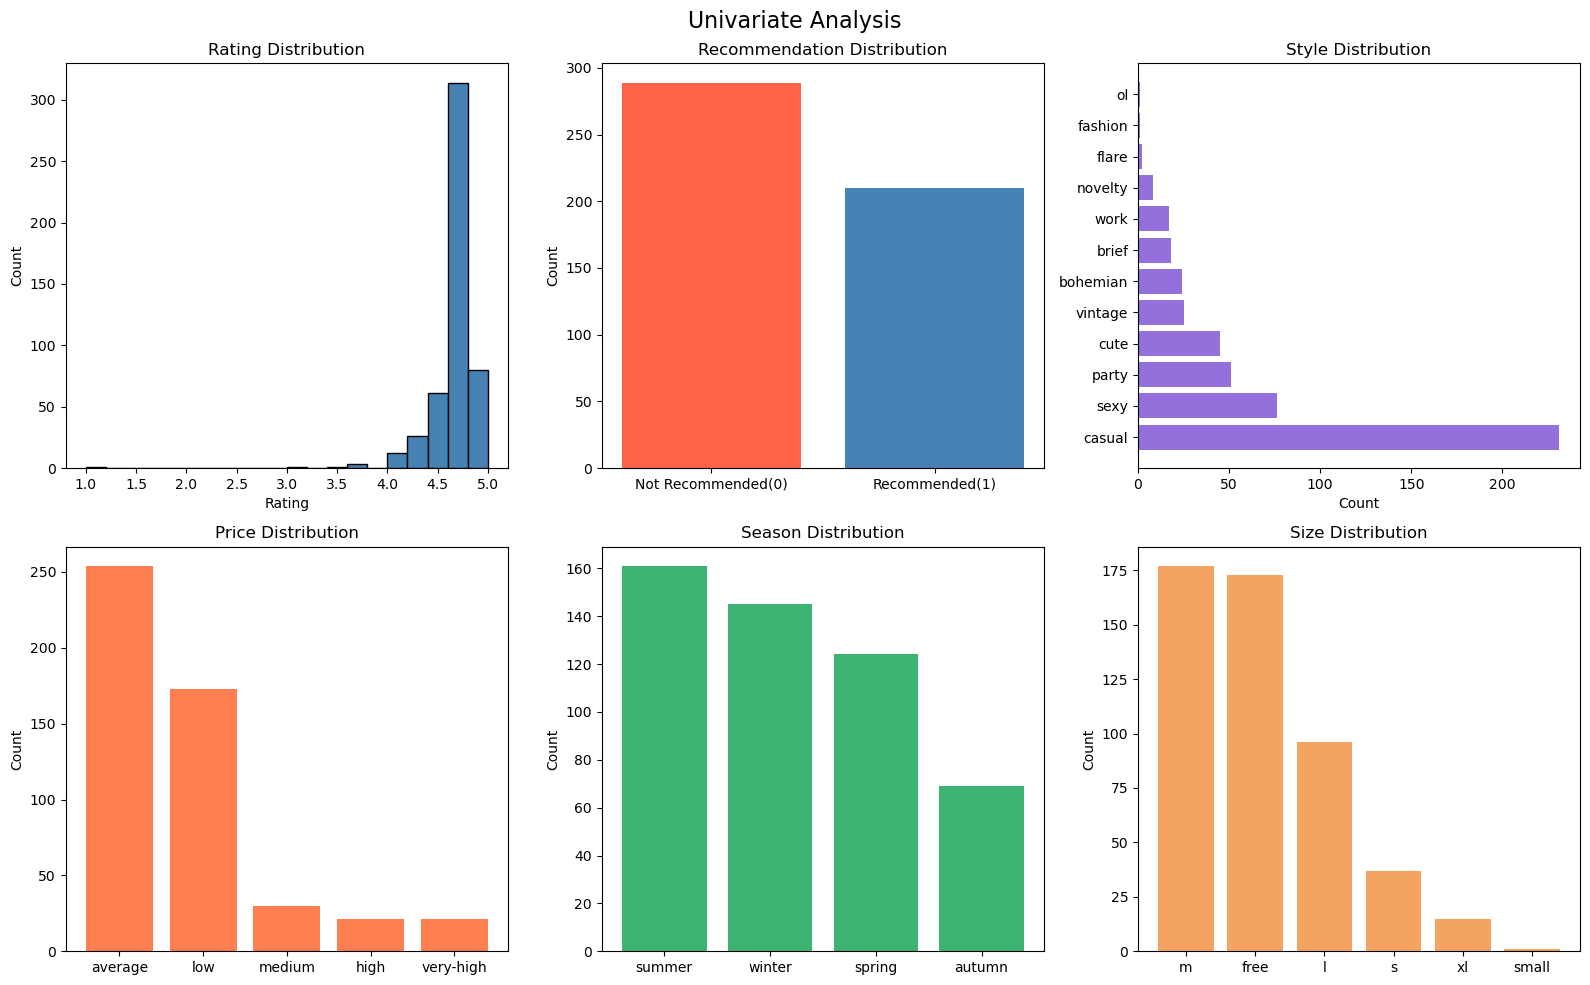

In [38]:
# ── PLOTS: Univariate MATPLOTLIB ──────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Univariate Analysis', fontsize=16)

# Rating histogram
axes[0,0].hist(df['Rating'], bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')

# Recommendation bar
rec_counts = df['Recommendation'].value_counts()
axes[0,1].bar(['Not Recommended(0)', 'Recommended(1)'],
               rec_counts.values, color=['tomato','steelblue'])
axes[0,1].set_title('Recommendation Distribution')
axes[0,1].set_ylabel('Count')

# Style bar
style_counts = df['Style'].value_counts()
axes[0,2].barh(style_counts.index, style_counts.values, color='mediumpurple')
axes[0,2].set_title('Style Distribution')
axes[0,2].set_xlabel('Count')

# Price bar
price_counts = df['Price'].value_counts()
axes[1,0].bar(price_counts.index, price_counts.values, color='coral')
axes[1,0].set_title('Price Distribution')
axes[1,0].set_ylabel('Count')

# Season bar
season_counts = df['Season'].value_counts()
axes[1,1].bar(season_counts.index, season_counts.values, color='mediumseagreen')
axes[1,1].set_title('Season Distribution')
axes[1,1].set_ylabel('Count')

# Size bar
size_counts = df['Size'].value_counts()
axes[1,2].bar(size_counts.index, size_counts.values, color='sandybrown')
axes[1,2].set_title('Size Distribution')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Bivariate Analysis

Bivariate analysis examines the relationship between two variables.
    
It helps identify how one variable influences or relates to another, which is crucial for discovering patterns and making data-driven decisions.

In [39]:
# BIVARIATE ANALYSIS

print("\n" + "=" * 55)
print("2. BIVARIATE ANALYSIS")
print("=" * 55)

# ── 2a. Rating vs Recommendation ──────────────────
print("\n-- Average Rating by Recommendation --")
print(df.groupby('Recommendation')['Rating'].mean().round(2))


2. BIVARIATE ANALYSIS

-- Average Rating by Recommendation --
Recommendation
1    4.64
2    4.68
Name: Rating, dtype: float64


In [40]:
# ── 2b. Style vs Recommendation ───────────────────
print("\n-- Style vs Recommendation --")
print(df.groupby('Style')['Recommendation'].mean().round(2))


-- Style vs Recommendation --
Style
bohemian    1.54
brief       1.22
casual      1.39
cute        1.49
fashion     1.00
flare       1.50
novelty     1.38
ol          1.00
party       1.69
sexy        1.42
vintage     1.32
work        1.18
Name: Recommendation, dtype: float64


C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\1683834160.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Style')['Recommendation'].mean().round(2))


In [41]:
# ── 2c. Price vs Recommendation ───────────────────
print("\n-- Price vs Recommendation --")
print(df.groupby('Price')['Recommendation'].mean().round(2))


-- Price vs Recommendation --
Price
average      1.37
high         1.43
low          1.42
medium       1.63
very-high    1.76
Name: Recommendation, dtype: float64


C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\4085252073.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Price')['Recommendation'].mean().round(2))


In [42]:
# ── 2d. Season vs Recommendation ──────────────────
print("\n-- Season vs Recommendation --")
print(df.groupby('Season')['Recommendation'].mean().round(2))


-- Season vs Recommendation --
Season
autumn    1.32
spring    1.60
summer    1.34
winter    1.40
Name: Recommendation, dtype: float64


C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\4083398652.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Season')['Recommendation'].mean().round(2))


In [43]:
# ── 2e. Season vs Rating ───────────────────────────
print("\n-- Average Rating by Season --")
print(df.groupby('Season')['Rating'].mean().round(2))


-- Average Rating by Season --
Season
autumn    4.63
spring    4.68
summer    4.65
winter    4.65
Name: Rating, dtype: float64


C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\3173630006.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Season')['Rating'].mean().round(2))


## Bivariate Analysis (Visualization using Seaborn)

In this section, we visualize the relationship between two variables using Matplotlib and Seaborn-style plots.

These visualizations help in identifying trends, correlations, and patterns between features such as rating, recommendation, price, style, and season.

C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\2700537204.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_rating = df.groupby('Season')['Rating'].mean()
C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\2700537204.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_rec = df.groupby('Season')['Recommendation'].value_counts().unstack()
C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\2700537204.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adop

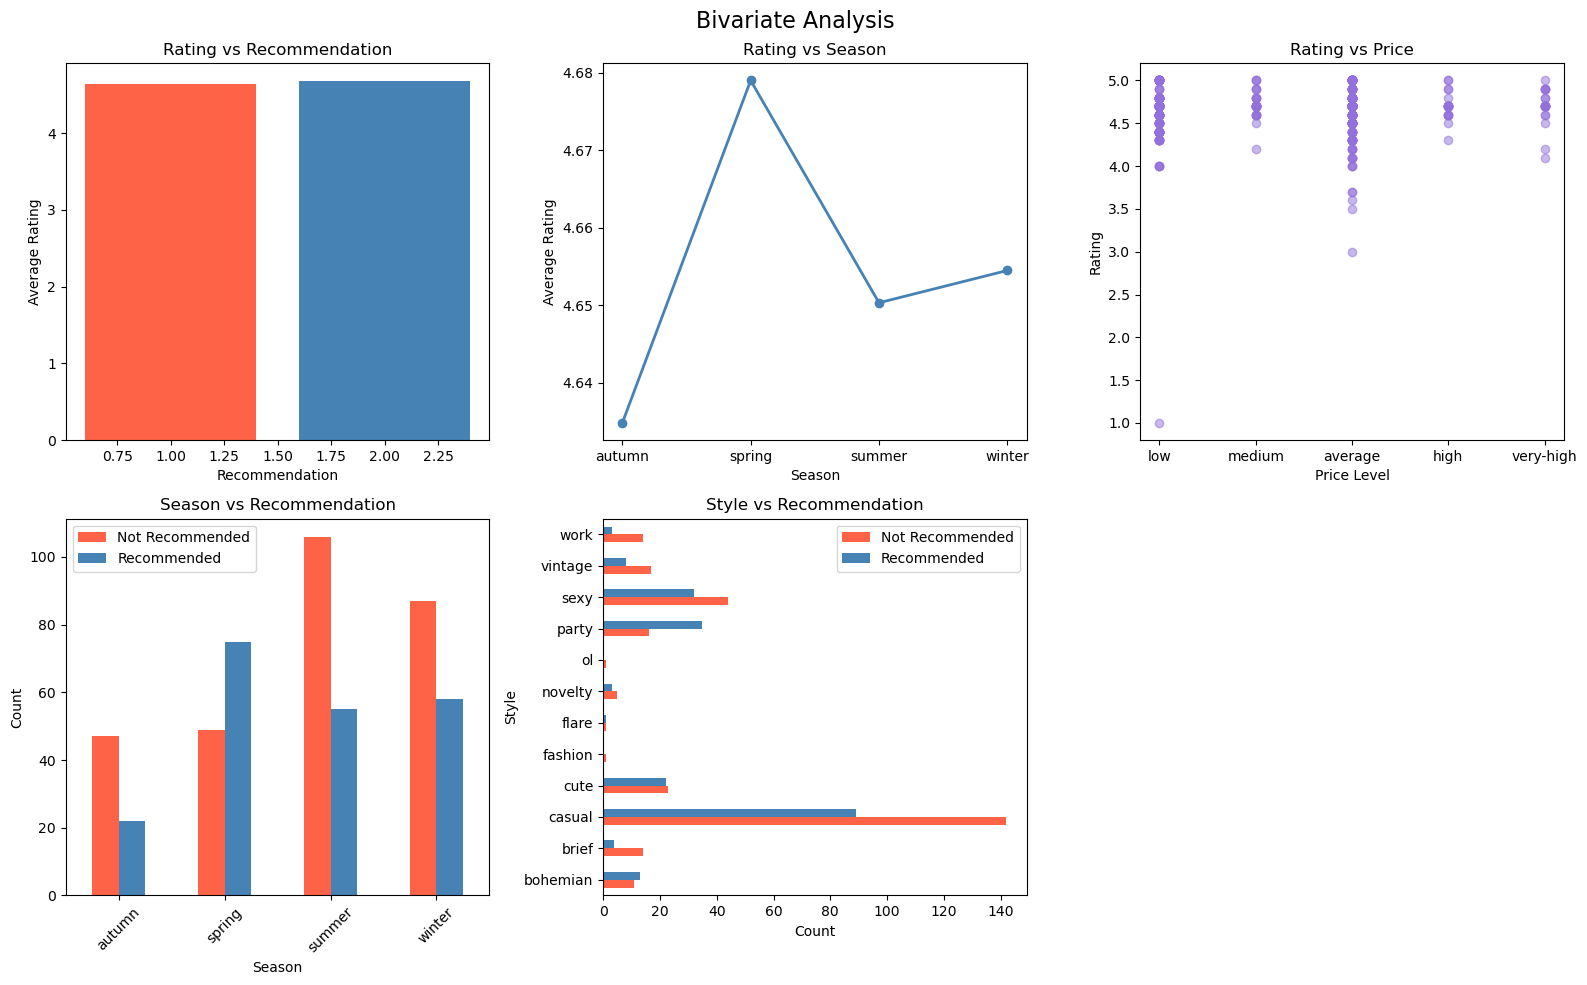

In [44]:
# ── PLOTS: Bivariate SEABORN ──────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bivariate Analysis', fontsize=16)

# Plot 1: Rating vs Recommendation - BAR CHART
rec_rating = df.groupby('Recommendation')['Rating'].mean()
axes[0,0].bar(rec_rating.index, rec_rating.values,
              color=['tomato', 'steelblue'])
axes[0,0].set_title('Rating vs Recommendation')
axes[0,0].set_xlabel('Recommendation')
axes[0,0].set_ylabel('Average Rating')

# Plot 2: Rating vs Season - LINE CHART
season_rating = df.groupby('Season')['Rating'].mean()
axes[0,1].plot(season_rating.index, season_rating.values,
               color='steelblue', marker='o', linewidth=2)
axes[0,1].set_title('Rating vs Season')
axes[0,1].set_xlabel('Season')
axes[0,1].set_ylabel('Average Rating')

# Plot 3: Rating vs Price - SCATTER CHART
price_mapping = {'low':1, 'medium':2, 'average':3, 
                 'high':4, 'very-high':5}
df['Price_num'] = df['Price'].map(price_mapping)
axes[0,2].scatter(df['Price_num'], df['Rating'],
                  color='mediumpurple', alpha=0.5)
axes[0,2].set_title('Rating vs Price')
axes[0,2].set_xlabel('Price Level')
axes[0,2].set_ylabel('Rating')
axes[0,2].set_xticks([1,2,3,4,5])
axes[0,2].set_xticklabels(['low','medium','average',
                            'high','very-high'])

# Plot 4: Season vs Recommendation - BAR CHART
season_rec = df.groupby('Season')['Recommendation'].value_counts().unstack()
season_rec.plot(kind='bar', ax=axes[1,0], 
                color=['tomato','steelblue'])
axes[1,0].set_title('Season vs Recommendation')
axes[1,0].set_xlabel('Season')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['Not Recommended', 'Recommended'])

# Plot 5: Style vs Recommendation - HORIZONTAL BAR CHART
style_rec = df.groupby('Style')['Recommendation'].value_counts().unstack()
style_rec.plot(kind='barh', ax=axes[1,1],
               color=['tomato','steelblue'])
axes[1,1].set_title('Style vs Recommendation')
axes[1,1].set_xlabel('Count')
axes[1,1].set_ylabel('Style')
axes[1,1].legend(['Not Recommended', 'Recommended'])

# Hide last empty plot
axes[1,2].set_visible(False)

plt.tight_layout()
plt.show()

## Multivariate Analysis

Multivariate analysis examines the relationship between more than two variables simultaneously. 

It provides deeper insights into how multiple factors interact and influence outcomes such as customer recommendations and ratings.

In [45]:
# MULTIVARIATE ANALYSIS

print("\n" + "=" * 55)
print("3. MULTIVARIATE ANALYSIS")
print("=" * 55)

result = df.groupby(['Style','Season'])['Recommendation']\
           .mean().round(2)\
           .fillna('No such combination')
print(result)


3. MULTIVARIATE ANALYSIS
Style     Season
bohemian  autumn                    1.5
          spring                    1.8
          summer                   1.55
          winter                   1.33
brief     autumn                    1.0
          spring                    1.8
          summer                    1.0
          winter                    1.0
casual    autumn                   1.42
          spring                   1.46
          summer                   1.28
          winter                   1.42
cute      autumn                    1.0
          spring                   1.94
          summer                   1.31
          winter                   1.25
fashion   autumn    No such combination
          spring    No such combination
          summer                    1.0
          winter    No such combination
flare     autumn    No such combination
          spring                    1.5
          summer    No such combination
          winter    No such combinati

C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\76931443.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(['Style','Season'])['Recommendation']\


In [46]:
# ── 3b. Price + Season vs Rating ──────────────────
print("\n-- Price + Season vs Avg Rating --")
result_b = df.groupby(['Price','Season'])['Rating']\
             .mean().round(2)\
             .fillna('No such combination')
print(result_b)


-- Price + Season vs Avg Rating --
Price      Season
average    autumn                   4.64
           spring                   4.65
           summer                   4.67
           winter                   4.65
high       autumn                    4.7
           spring                   4.65
           summer                   4.78
           winter                   4.69
low        autumn                    4.6
           spring                   4.67
           summer                   4.61
           winter                   4.66
medium     autumn                   4.85
           spring                   4.74
           summer                   4.75
           winter                   4.69
very-high  autumn    No such combination
           spring                   4.81
           summer                    4.6
           winter                   4.58
Name: Rating, dtype: object


C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\430775687.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_b = df.groupby(['Price','Season'])['Rating']\


In [47]:
# ── 3c. Style + Price vs Recommendation ───────────
print("\n-- Style + Price vs Recommendation --")
result_c = df.groupby(['Style','Price'])['Recommendation']\
             .mean().round(2)\
             .fillna('No such combination')
print(result_c)


-- Style + Price vs Recommendation --
Style     Price    
bohemian  average                      1.3
          high         No such combination
          low                         1.67
          medium                       2.0
          very-high                    2.0
brief     average                     1.31
          high         No such combination
          low                          1.0
          medium       No such combination
          very-high    No such combination
casual    average                     1.36
          high                        1.67
          low                         1.37
          medium                      1.67
          very-high                    1.5
cute      average                     1.38
          high                        1.67
          low                         1.47
          medium                       2.0
          very-high    No such combination
fashion   average                      1.0
          high         No such combina

C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\881960711.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_c = df.groupby(['Style','Price'])['Recommendation']\


## Multivariate Analysis (Interactive Visualization using Plotly)

In this section, we use Plotly to create interactive visualizations for multivariate analysis. 
    
These plots help in understanding how multiple variables (Style, Season, Price, Recommendation, Rating) interact with each other in a dynamic and visually appealing way.

In [48]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# ── 3a. Style + Season vs Recommendation ──────────
result_a = df.groupby(['Style','Season'])['Recommendation']\
             .mean().round(2).dropna().unstack()

fig_a = px.bar(result_a,
               barmode='group',
               title='Style + Season vs Recommendation',
               labels={'value':'Avg Recommendation',
                       'Style':'Style'},
               color_discrete_sequence=[
                   '#FF0000',  # Red
                   '#FF6600',  # Orange
                   '#FFFF00',  # Yellow
                   '#00FF00',  # Green
               ])
fig_a.update_layout(
                  title_font_size=16,
                  legend_title='Season',
                  xaxis_title='Style',
                  yaxis_title='Avg Recommendation',
                  width=900,
                  height=600,
                  plot_bgcolor='white',
                  bargap=0.2)
fig_a.show()

# ── 3b. Price + Season vs Rating ──────────────────
result_b = df.groupby(['Price','Season'])['Rating']\
             .mean().round(2).dropna().unstack()

# Reorder price levels
price_order = ['low', 'medium', 'average', 'high', 'very-high']
result_b = result_b.reindex(price_order)

fig_b = px.line(result_b,
                title='Price + Season vs Avg Rating',
                labels={'value':'Avg Rating',
                        'Price':'Price Level'},
                markers=True,
                color_discrete_sequence=px.colors.qualitative.Vivid)
fig_b.update_layout(
                title_font_size=16,
                legend_title='Season',
                xaxis_title='Price Level',
                yaxis_title='Avg Rating',
                width=900,
                height=600,
                plot_bgcolor='white')
fig_b.show()

# ── 3c. Style + Price vs Recommendation ───────────
result_c = df.groupby(['Style','Price'])['Recommendation']\
             .mean().round(2).unstack().fillna(0)

fig_c = px.imshow(result_c,
                  title='Style + Price vs Recommendation',
                  color_continuous_scale='RdYlGn',
                  aspect='auto',
                  text_auto=True)
fig_c.update_layout(
                  title_font_size=16,
                  xaxis_title='Price',
                  yaxis_title='Style',
                  width=800,
                  height=600)
fig_c.show()

C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\2519772609.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_a = df.groupby(['Style','Season'])['Recommendation']\


C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\2519772609.py:32: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



C:\Users\Rosem\AppData\Local\Temp\ipykernel_21212\2519772609.py:56: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



## Correlation Analysis

Correlation analysis is used to measure the strength and direction of relationships between numerical variables. 

It helps identify whether variables move together and how strongly they are related.

In [49]:
print("\n" + "=" * 55)
print("CORRELATION ANALYSIS")
print("=" * 55)

# Select numeric columns only
numeric_cols = df.select_dtypes(include='number').columns
print("\n-- Correlation Matrix --")
print(df[numeric_cols].corr().round(2))

# Key correlation
print(f"\n-- Key Correlations --")
print(f"Rating vs Recommendation : {df['Rating'].corr(df['Recommendation']):.2f}")
print(f"Rating vs Price_num      : {df['Rating'].corr(df['Price_num']):.2f}")
print(f"Price  vs Recommendation : {df['Price_num'].corr(df['Recommendation']):.2f}")


CORRELATION ANALYSIS

-- Correlation Matrix --
                Rating  Recommendation
Rating            1.00            0.06
Recommendation    0.06            1.00

-- Key Correlations --
Rating vs Recommendation : 0.06
Rating vs Price_num      : 0.05
Price  vs Recommendation : 0.04


## Correlation Analysis (Interactive Heatmap using Plotly)

In this section, we visualize the correlation between numerical variables using an interactive heatmap. 

This helps in quickly identifying the strength and direction of relationships between variables such as Rating, Recommendation, and Price.

In [50]:
import plotly.express as px

# Correlation matrix
corr_matrix = df[['Rating', 
                  'Recommendation',
                  'Price_num']].corr().round(2)

# Heatmap
fig = px.imshow(corr_matrix,
                title='Correlation Heatmap',
                color_continuous_scale='RdYlGn',
                text_auto=True,
                aspect='auto',
                zmin=-1,    # minimum correlation
                zmax=1)     # maximum correlation
fig.update_layout(
                title_font_size=16,
                width=600,
                height=500)
fig.show()

## Outlier Treatment

Outlier treatment is used to identify and handle extreme values in the dataset that may negatively affect analysis. 
    
In this section, we use the Interquartile Range (IQR) method to detect outliers in the Rating column.

In [51]:
print("\n" + "=" * 55)
print("OUTLIER TREATMENT")
print("=" * 55)

# Step 1: Calculate bounds
Q1 = df['Rating'].quantile(0.25)
Q3 = df['Rating'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Step 2: Find outliers
outlier_rows = df[(df['Rating'] < lower) | (df['Rating'] > upper)]

print(f"\n-- Outlier Summary --")
print(f"Q1            : {Q1}")
print(f"Q3            : {Q3}")
print(f"IQR           : {IQR}")
print(f"Lower Bound   : {lower:.2f}")
print(f"Upper Bound   : {upper:.2f}")
print(f"Outliers Found: {len(outlier_rows)}")




OUTLIER TREATMENT

-- Outlier Summary --
Q1            : 4.6
Q3            : 4.8
IQR           : 0.20000000000000018
Lower Bound   : 4.30
Upper Bound   : 5.10
Outliers Found: 24


## Outlier Treatment (Removal & Verification)

In this section, we not only detect outliers but also analyze, remove, and verify them. A threshold-based approach is used to filter out ratings below 3.5, ensuring improved data quality for further analysis.

3. Shows rows identified as outliers for manual inspection.

4. Shows rows identified as outliers for manual inspection.

5. Removes low-rated entries to improve dataset consistency.

6. Ensures:

Minimum rating is above threshold
Dataset is clean
No outliers remain

In [52]:
# Step 3: Show outlier rows
print(f"\n-- Outlier Rows --")
print(outlier_rows[['Style','Price','Rating',
                     'Season','Recommendation']])


-- Outlier Rows --
        Style      Price  Rating  Season  Recommendation
22      brief        low     4.0  summer               1
64       sexy        low     4.0  autumn               2
72       sexy    average     4.2  winter               1
87       sexy    average     4.0  autumn               2
100   fashion    average     4.0  summer               1
119      sexy    average     3.6  winter               2
162    casual    average     3.7  autumn               2
201    casual    average     4.1  autumn               2
242    casual    average     3.5  winter               1
274     party  very-high     4.2  winter               2
276     party  very-high     4.1  winter               2
311    casual    average     4.2  winter               1
314    casual    average     3.7  summer               1
322   novelty     medium     4.2  winter               2
356   vintage        low     4.0  summer               1
363    casual    average     4.1  winter               2
364    casu

In [53]:
# Step 4: Find outliers below 3.5
outlier_rows = df[df['Rating'] < 3.5]

print(f"\n-- Outlier Summary --")
print(f"Threshold     : 3.5")
print(f"Outliers Found: {len(outlier_rows)}")
print(f"\n-- Outlier Rows --")
print(outlier_rows[['Style','Price','Rating',
                     'Season','Recommendation']])


-- Outlier Summary --
Threshold     : 3.5
Outliers Found: 2

-- Outlier Rows --
      Style    Price  Rating  Season  Recommendation
373  casual      low     1.0  spring               1
406  casual  average     3.0  spring               1


In [54]:
# Step 5: Remove
print(f"\n-- Removing Outliers --")
print(f"Rows before   : {len(df)}")
df = df[df['Rating'] >= 3.5]
print(f"Rows after    : {len(df)}")
print(f"Rows removed  : {len(outlier_rows)}")


-- Removing Outliers --
Rows before   : 499
Rows after    : 497
Rows removed  : 2


In [55]:
# Step 6: Verify
print(f"\n-- Verification --")
print(f"New Min Rating : {df['Rating'].min()}")
print(f"New Max Rating : {df['Rating'].max()}")
print(f"New Mean Rating: {df['Rating'].mean():.2f}")
print(f"Outliers remaining: {len(df[df['Rating'] < 3.5])}")


-- Verification --
New Min Rating : 3.5
New Max Rating : 5.0
New Mean Rating: 4.67
Outliers remaining: 0


## Visualization After Outlier Removal

After removing outliers, it is important to visualize the updated data distribution. 

This helps verify the effectiveness of the cleaning process and understand how the dataset has improved.

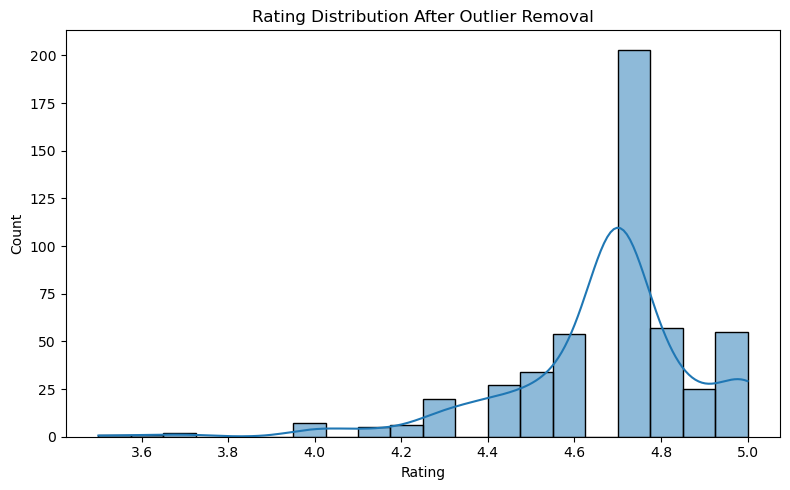

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.close('all')

df_clean = df[df['Rating'] >= 3.5]

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(df_clean['Rating'],
             bins=20,
             kde=True,
             ax=ax)

ax.set_title('Rating Distribution After Outlier Removal')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()




In [57]:
print("\n" + "=" * 55)
print("SAVING FINAL CLEANED DATA")
print("=" * 55)

# Save to CSV
df.to_csv(r"C:\Users\Rosem\OneDrive\Desktop\DATA ANAYLTICS ASSIGNMENT\Phython Programs assignment\fashion_sales_cleaned.csv", 
          index=False)

print(f"File saved successfully!")
print(f"Total Rows    : {len(df)}")
print(f"Total Columns : {len(df.columns)}")
print(f"Columns saved : {list(df.columns)}")


SAVING FINAL CLEANED DATA
File saved successfully!
Total Rows    : 497
Total Columns : 17
Columns saved : ['Style', 'Price', 'Rating', 'Size', 'Season', 'NeckLine', 'SleeveLength', 'Waistline', 'Material', 'FabricType', 'Decoration', 'PatternType', 'Recommendation', 'RatingCategory', 'PriceLevel', 'IsRecommended', 'Price_num']


In [58]:
## Recheck saved file

df_check = pd.read_csv(r"C:\Users\Rosem\OneDrive\Desktop\DATA ANAYLTICS ASSIGNMENT\Phython Programs assignment\fashion_sales_cleaned.csv")

print(f"Rows    : {df_check.shape[0]}")
print(f"Columns : {df_check.shape[1]}")
print(df_check.head())

Rows    : 497
Columns : 17
     Style    Price  Rating Size  Season NeckLine SleeveLength Waistline  \
0     sexy      low     4.6    m  summer   o-neck   sleeveless    empire   
1   casual      low     4.7    l  summer   o-neck        petal   natural   
2  vintage     high     4.7    l  autumn   o-neck         full   natural   
3    brief  average     4.6    l  spring   o-neck         full   natural   
4     cute      low     4.5    m  summer   o-neck    butterfly   natural   

     Material FabricType  Decoration PatternType  Recommendation  \
0      cotton    chiffon     ruffles      animal               2   
1  microfiber    chiffon     ruffles      animal               1   
2   polyester    chiffon        lace       print               1   
3        silk    chiffon  embroidary       print               2   
4     chiffon    chiffon         bow         dot               1   

  RatingCategory  PriceLevel    IsRecommended  Price_num  
0      Excellent           1  Not Recommended   

## KEY INSIGHTS


1. Data Quality & Cleaning

The raw dataset had significant quality issues — missing values disguised as ?, 
120 zero ratings (invalid on a 1–5 scale), 
inconsistent text casing, and multiple spelling errors across columns like SleeveLength, Material, and FabricType. 
All of these were systematically resolved before any analysis.

2. Rating Distribution

After replacing zero ratings with the median and removing outliers below 3.5, the rating distribution is heavily left-skewed — 
the vast majority of dresses are rated between 4.5 and 4.8, with a dominant peak at 4.7. 
This is typical of e-commerce fashion data where customers tend to rate products they liked.

3. Recommendation Pattern

The dataset is imbalanced — a large portion of dresses are marked as "Recommended" (1) over "Not Recommended" (2). 
This suggests the catalog is generally well-received by customers.

4. Style & Season Trends

Casual style is the most frequently occurring dress style in the dataset.
Season-wise, dresses are fairly distributed across Summer, Autumn, Winter, and Spring, with Summer being a dominant category.
Multivariate analysis showed that recommendation rates vary across Style + Season combinations, meaning seasonal preferences significantly affect customer satisfaction.


5. Price vs Rating
The scatter analysis between price level and rating showed no strong linear correlation — meaning higher-priced dresses don't necessarily receive higher ratings. This indicates that style, fit, and quality perception matter more than price alone.

6. Correlation Analysis

Rating vs Recommendation showed a weak-to-moderate positive correlation — higher-rated dresses are slightly more likely to be recommended.
Price vs Recommendation showed a very weak correlation — confirming price alone doesn't drive recommendations.

7. Outlier Treatment

Using the IQR method and a minimum threshold of 3.5, a small number of low-rated dresses were removed. 
This improved the dataset consistency and ensured the final analysis reflects the true performance of mainstream fashion products.